# Notebook 1 (V4_3) — Fixed-$\nu_b$ Unbalanced-Growth Branch (No Common-Growth Condition)

This notebook is an isolated replication of
`Two_country_production_common_growth/03_v9_unbalanced_branch.ipynb`.  It uses
the solver in `Two_country_proudction_fixed_nu_b`, fixes
$\nu_b=\xi_W=1.0$, and sets `common_world_growth=false`.  Thus the absorbing
successor at every state is solved with the same primitive $\nu_b$; there is
**no state-by-state recalibration of $\nu_b$** to impose $G_b=G_W$.

Along the all-$u$ history $z_0 = z_1 = \cdots = z_{t-1} = u$, the
equilibrium policy vector follows V4_3's reduced state-by-state
characterization (V4_3 lines 745–855):
$$
x_t^u = (\varphi_{US,t}^u,\, \varphi_{W,t},\, \omega_t,\,
         \theta_{US,t}^*,\, \omega_t^*,\, R_{f,t},\, R_{f,t}^W).
$$
The bond shares are recovered from zero-net-supply clearing
(V4_3 lines 800–802): $\theta_{W,t}^* = 0$ and
$\theta_t = -\theta_{US,t}^*\,A_t^*/A_t$.

Successors at $t+1$ (V4_3 `recursive_next_state`, line 629 and
Branch Reduction Lemma `lem_branch_reduction`, line 1344):
- continuation in $u$ with probability $\pi$ → use $x_{t+1}^u$;
- switch to $b$ with probability $1-\pi$ → solve the absorbing equilibrium at
  the same predetermined state $(N_{US,t+1}^u,N_{W,t+1})$, holding
  $\nu_b=\xi_W=1.0$ fixed.

The forward-backward iteration:
1. Forward-compute $\{N_{US,t}^u\}$ and $\{N_{W,t}\}$ from current
   $\{\varphi_{US,t}^u,\varphi_{W,t}\}$.
2. Solve the fixed-$\nu_b$ absorbing equilibrium at every
   $(N_{US,t+1}^u,N_{W,t+1})$.
3. Backward-induct $x_t^u$ for $t=T,T-1,\ldots,1$.
4. Update the $\varphi$ paths and iterate to convergence.

The V4_3 prediction (Lemma `lem_prod_orders`, eq. `phi_u_upper_order`) is the
one-sided **upper** bound
$\varphi_{US,t}^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}}$, so the
per-variety dividend yield $d^u/q^u$ collapses and $q_{US}^u/d_{US}^u$ rises.
The calibration below is the same AHP-matching calibration used in fixed-$\nu_b$
Notebooks 02 and 03.  Relative to the common-growth source, it remains a
fixed-$\nu_b$ counterfactual because the absorbing exponent is never
recalibrated state by state.

### AHP calibration and verified extended horizon

The source notebook used `T_max=100`.  With the AHP-matching parameters, the
fixed-$\nu_b$ no-buffer continuation is hard-valid through $T=137$.  The
notebook solves the documented grid $30,35,\ldots,135,136,137$, always warm
starting from the preceding solved path.  Thus all figures below report a
genuinely solved $T=137$ equilibrium rather than an extrapolated tail.


In [1]:
using Pkg

const FIXED_NU_B_DIRNAME = "Two_country_proudction_fixed_nu_b"
const MODEL_CANDIDATES = unique(normpath.([
    joinpath(pwd(), FIXED_NU_B_DIRNAME, "TwoCountryProductionOLG.jl"),
    joinpath(pwd(), "Codes", FIXED_NU_B_DIRNAME, "TwoCountryProductionOLG.jl"),
    joinpath(dirname(pwd()), FIXED_NU_B_DIRNAME, "TwoCountryProductionOLG.jl"),
]))

model_idx = findfirst(isfile, MODEL_CANDIDATES)
isnothing(model_idx) && error(
    "Cannot find the fixed-nu_b solver. Checked:\n" * join(MODEL_CANDIDATES, "\n")
)
MODEL_FILE = MODEL_CANDIDATES[model_idx]
CODES_ROOT = dirname(dirname(MODEL_FILE))
Pkg.activate(CODES_ROOT)
include(MODEL_FILE)

using Plots, LaTeXStrings, Printf, Markdown
gr()

const EXPERIMENT_LABEL = "AHP-matching calibration; fixed nu_b = xi_W = 1.0; common growth disabled"
@info "Loaded isolated fixed-nu_b solver" MODEL_FILE CODES_ROOT


  Activating 

project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`
┌ Info: Loaded isolated fixed-nu_b solver
│   MODEL_FILE = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/Two_country_proudction_fixed_nu_b/TwoCountryProductionOLG.jl"
└   CODES_ROOT = "/Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes"


In [2]:
const SOURCE_NOTEBOOK_HORIZON = 100
const VERIFIED_FIXED_NU_B_HORIZON = 137
const FIXED_NU_B_CONTINUATION_HORIZONS = vcat(collect(30:5:135), [136, 137])
const FIXED_NU_B_BRANCH_ITERS = 500
const FIXED_NU_B_RESID_TOL = 1e-5
const FIXED_NU_B_PSI_TOL = 0.02
const FIXED_NU_B_EQUITY_TOL = 0.01
const FIXED_NU_B_THETA_TOL = 0.01

const AHP_CALIBRATION = (
    β=0.45, γ=0.25, π_persist=0.75,
    a_US=0.20, ϑ_US=0.85,
    a_W=0.06, H_W=3.0, L_W=3.0,
    A_X_US_u=15.0, A_L_US_u=1.5,
    ν_b_fixed=1.0, ν_u=1.75, ξ_u=2.25, ξ_W=1.0,
    ω̄=0.50, ω̄_star=0.25,
    κ=1.0, χ=0.0002, η=0.010,
    common_world_growth=false,
)

function fixed_nu_b_hard_validity(result; tol=FIXED_NU_B_RESID_TOL)
    residual_safe = result.branch_converged &&
        isfinite(result.max_u_residual) && result.max_u_residual <= tol &&
        isfinite(result.max_bgp_residual) && result.max_bgp_residual <= tol
    all_bgp_valid = !isempty(result.bgp_seq) && all(
        b -> b.converged && isfinite(b.residual_norm) && b.residual_norm <= tol,
        result.bgp_seq,
    )
    psi_regular = result.diagnostics.psi_ok &&
        isfinite(result.diagnostics.psi_min) &&
        result.diagnostics.psi_min >= FIXED_NU_B_PSI_TOL
    equity_regular = result.diagnostics.equity_weights_ok &&
        isfinite(result.diagnostics.equity_weight_min) &&
        result.diagnostics.equity_weight_min >= FIXED_NU_B_EQUITY_TOL
    theta_path = [s.θ_US_star for s in result.u_path]
    theta_interior = all(
        x -> isfinite(x) && FIXED_NU_B_THETA_TOL <= x < 0.9, theta_path)
    fixed_exponent_error = maximum(abs.([
        b.ν_b_eff - result.params.ν_b for b in result.bgp_seq
    ]))
    exponent_fixed = isfinite(fixed_exponent_error) && fixed_exponent_error <= 1e-12
    valid = residual_safe && all_bgp_valid && psi_regular &&
        equity_regular && theta_interior && exponent_fixed
    return (;
        valid, residual_safe, all_bgp_valid, psi_regular, equity_regular,
        theta_interior, theta_min=minimum(theta_path),
        exponent_fixed, fixed_exponent_error,
    )
end

continuation_rows = NamedTuple[]
warm_result = nothing
for horizon in FIXED_NU_B_CONTINUATION_HORIZONS
    warm_T = warm_result === nothing ? missing : length(warm_result.u_path)
    c = AHP_CALIBRATION
    p_candidate = ProductionParams(
        T_max=horizon,
        n_buffer=0,
        branch_iters=FIXED_NU_B_BRANCH_ITERS,
        β=c.β, γ=c.γ, π_persist=c.π_persist,
        a_US=c.a_US, ϑ_US=c.ϑ_US,
        a_W=c.a_W, H_W=c.H_W, L_W=c.L_W,
        A_X_US_u=c.A_X_US_u, A_L_US_u=c.A_L_US_u,
        ν_b=c.ν_b_fixed, ν_u=c.ν_u, ξ_u=c.ξ_u, ξ_W=c.ξ_W,
        ω̄=c.ω̄, ω̄_star=c.ω̄_star,
        κ=c.κ, χ=c.χ, η=c.η,
        common_world_growth=c.common_world_growth,
    )
    @assert p_candidate.ν_b == 1.0 && p_candidate.ξ_W == 1.0
    @assert !p_candidate.common_world_growth
    started = time()
    candidate = run_production_simulation(
        p_candidate;
        verbose=false,
        initial_u_path=(warm_result === nothing ? nothing : warm_result.u_path_extended),
    )
    elapsed_sec = time() - started
    validity = fixed_nu_b_hard_validity(candidate)
    push!(continuation_rows, (;
        horizon,
        warm_start_T=warm_T,
        elapsed_sec,
        branch_converged=candidate.branch_converged,
        max_u_residual=candidate.max_u_residual,
        max_bgp_residual=candidate.max_bgp_residual,
        psi_min=candidate.diagnostics.psi_min,
        equity_weight_min=candidate.diagnostics.equity_weight_min,
        theta_US_star_min=validity.theta_min,
        hard_valid=validity.valid,
    ))
    @printf(
        "T=%d warm_T=%s: hard_valid=%s, max u/bgp residual=%.3e / %.3e\n",
        horizon, ismissing(warm_T) ? "cold" : string(warm_T),
        validity.valid, candidate.max_u_residual, candidate.max_bgp_residual,
    )
    @assert validity.valid "fixed-nu_b continuation failed the equilibrium hard-validity gate at T=$(horizon)"
    warm_result = candidate
end

result = warm_result
p = result.params
@assert p.T_max == VERIFIED_FIXED_NU_B_HORIZON
@assert p.n_buffer == 0 && p.branch_iters == FIXED_NU_B_BRANCH_ITERS
@assert p.ν_b == 1.0 && p.ξ_W == 1.0 && !p.common_world_growth
resolved_AHP_calibration = (
    β=p.β, γ=p.γ, π_persist=p.π_persist,
    a_US=p.a_US, ϑ_US=p.ϑ_US, a_W=p.a_W, H_W=p.H_W, L_W=p.L_W,
    A_X_US_u=p.A_X_US_u, A_L_US_u=p.A_L_US_u,
    ν_b_fixed=p.ν_b, ν_u=p.ν_u, ξ_u=p.ξ_u, ξ_W=p.ξ_W,
    ω̄=p.ω̄, ω̄_star=p.ω̄_star, κ=p.κ, χ=p.χ, η=p.η,
    common_world_growth=p.common_world_growth,
)
@assert resolved_AHP_calibration == AHP_CALIBRATION
final_validity = fixed_nu_b_hard_validity(result)
@assert final_validity.valid

# The AHP calibration satisfies the primitive exponent ordering.  This is
# necessary but not sufficient for the independent infinite-tail HKT gate.
@assert p.ξ_u > p.ν_u > p.ν_b >= 0

continuation_table_lines = [
    "| solved T | warm start T | seconds | max u residual | max BGP residual | min Psi | min equity slack | min theta_US* | equilibrium hard-valid |",
    "|---:|---:|---:|---:|---:|---:|---:|---:|:---:|",
]
append!(continuation_table_lines, [
    @sprintf("| %d | %s | %.2f | %.3e | %.3e | %.6f | %.6f | %.6f | %s |",
             r.horizon, ismissing(r.warm_start_T) ? "cold" : string(r.warm_start_T),
             r.elapsed_sec, r.max_u_residual, r.max_bgp_residual,
             r.psi_min, r.equity_weight_min, r.theta_US_star_min, r.hard_valid)
    for r in continuation_rows
])
display(Markdown.parse(join(continuation_table_lines, "\n")))

@printf("Source notebook horizon: %d; verified AHP fixed-nu_b horizon: %d\n",
        SOURCE_NOTEBOOK_HORIZON, p.T_max)
@printf("AHP calibration: beta=%.2f, gamma=%.2f, pi=%.2f, nu_u=%.2f, xi_u=%.2f\n",
        p.β, p.γ, p.π_persist, p.ν_u, p.ξ_u)
@printf("Fixed-exponent experiment: ν_b=%.1f, ξ_W=%.1f, common_world_growth=%s\n",
        p.ν_b, p.ξ_W, p.common_world_growth)
@printf("u-branch converged: %s   max ‖F_u‖ = %.2e\n",
        result.branch_converged, result.max_u_residual)
@printf("V4_3 equity-weight min slack: %.4e   ok=%s\n",
        result.diagnostics.equity_weight_min, result.diagnostics.equity_weights_ok)


T=30 warm_T=cold: hard_valid=true, max u/bgp residual=1.312e-07 / 2.164e-11
T=35 warm_T=30: hard_valid=true, max u/bgp residual=1.223e-07 / 2.164e-11


T=40 warm_T=35: hard_valid=true, max u/bgp residual=1.138e-07 / 9.407e-10
T=45 warm_T=40: hard_valid=true, max u/bgp residual=1.360e-07 / 9.412e-10
T=50 warm_T=45: hard_valid=true, max u/bgp residual=1.207e-07 / 9.412e-10
T=55 warm_T=50: hard_valid=true, max u/bgp residual=1.289e-07 / 9.412e-10
T=60 warm_T=55: hard_valid=true, max u/bgp residual=1.468e-07 / 9.412e-10
T=65 warm_T=60: hard_valid=true, max u/bgp residual=1.655e-07 / 9.412e-10


T=70 warm_T=65: hard_valid=true, max u/bgp residual=1.636e-07 / 9.412e-10
T=75 warm_T=70: hard_valid=true, max u/bgp residual=1.579e-07 / 9.412e-10
T=80 warm_T=75: hard_valid=true, max u/bgp residual=1.877e-07 / 9.412e-10
T=85 warm_T=80: hard_valid=true, max u/bgp residual=1.842e-07 / 9.412e-10
T=90 warm_T=85: hard_valid=true, max u/bgp residual=2.069e-07 / 9.412e-10
T=95 warm_T=90: hard_valid=true, max u/bgp residual=2.950e-07 / 9.412e-10


T=100 warm_T=95: hard_valid=true, max u/bgp residual=3.113e-07 / 9.412e-10
T=105 warm_T=100: hard_valid=true, max u/bgp residual=3.893e-07 / 9.412e-10
T=110 warm_T=105: hard_valid=true, max u/bgp residual=4.709e-07 / 9.412e-10
T=115 warm_T=110: hard_valid=true, max u/bgp residual=5.513e-07 / 9.412e-10


T=120 warm_T=115: hard_valid=true, max u/bgp residual=7.301e-07 / 9.412e-10
T=125 warm_T=120: hard_valid=true, max u/bgp residual=8.586e-07 / 9.412e-10


T=130 warm_T=125: hard_valid=true, max u/bgp residual=1.078e-06 / 9.412e-10
T=135 warm_T=130: hard_valid=true, max u/bgp residual=1.297e-06 / 9.412e-10
T=136 warm_T=135: hard_valid=true, max u/bgp residual=1.618e-06 / 9.412e-10
T=137 warm_T=136: hard_valid=true, max u/bgp residual=1.633e-06 / 9.412e-10


| solved T | warm start T | seconds | max u residual | max BGP residual |  min Psi | min equity slack | min theta_US* | equilibrium hard-valid |
| --------:| ------------:| -------:| --------------:| ----------------:| --------:| ----------------:| -------------:|:----------------------:|
|       30 |         cold |    7.39 |      1.312e-07 |        2.164e-11 | 0.930575 |         0.197055 |      0.036408 |          true          |
|       35 |           30 |    0.52 |      1.223e-07 |        2.164e-11 | 0.928102 |         0.195426 |      0.034574 |          true          |
|       40 |           35 |    0.03 |      1.138e-07 |        9.407e-10 | 0.925707 |         0.193871 |      0.032914 |          true          |
|       45 |           40 |    0.02 |      1.360e-07 |        9.412e-10 | 0.923389 |         0.192385 |      0.031371 |          true          |
|       50 |           45 |    0.02 |      1.207e-07 |        9.412e-10 | 0.921169 |         0.190982 |      0.029916 |          true          |
|       55 |           50 |    0.02 |      1.289e-07 |        9.412e-10 | 0.919096 |         0.189692 |      0.028547 |          true          |
|       60 |           55 |    0.02 |      1.468e-07 |        9.412e-10 | 0.917255 |         0.188572 |      0.027274 |          true          |
|       65 |           60 |    0.01 |      1.655e-07 |        9.412e-10 | 0.915779 |         0.187708 |      0.026117 |          true          |
|       70 |           65 |    0.02 |      1.636e-07 |        9.412e-10 | 0.914862 |         0.187228 |      0.025109 |          true          |
|       75 |           70 |    0.02 |      1.579e-07 |        9.412e-10 | 0.914694 |         0.187183 |      0.024291 |          true          |
|       80 |           75 |    0.01 |      1.877e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.023709 |          true          |
|       85 |           80 |    0.03 |      1.842e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.023407 |          true          |
|       90 |           85 |    0.04 |      2.069e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.023324 |          true          |
|       95 |           90 |    0.04 |      2.950e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.023305 |          true          |
|      100 |           95 |    0.05 |      3.113e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.023303 |          true          |
|      105 |          100 |    0.05 |      3.893e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.023302 |          true          |
|      110 |          105 |    0.06 |      4.709e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.023296 |          true          |
|      115 |          110 |    0.06 |      5.513e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.021484 |          true          |
|      120 |          115 |    0.07 |      7.301e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.018827 |          true          |
|      125 |          120 |    0.08 |      8.586e-07 |        9.412e-10 | 0.914693 |         0.187183 |      0.015833 |          true          |
|      130 |          125 |    0.08 |      1.078e-06 |        9.412e-10 | 0.914693 |         0.187183 |      0.012999 |          true          |
|      135 |          130 |    0.07 |      1.297e-06 |        9.412e-10 | 0.914693 |         0.187183 |      0.010715 |          true          |
|      136 |          135 |    0.06 |      1.618e-06 |        9.412e-10 | 0.914693 |         0.187183 |      0.010374 |          true          |
|      137 |          136 |    0.05 |      1.633e-06 |        9.412e-10 | 0.914693 |         0.187183 |      0.010075 |          true          |


Source notebook horizon: 100; verified AHP fixed-nu_b horizon: 137
AHP calibration: beta=0.45, gamma=0.25, pi=0.75, nu_u=1.75, xi_u=2.25


Fixed-exponent experiment: ν_b=1.0, ξ_W=1.0, common_world_growth=false
u-branch converged: true   max ‖F_u‖ = 1.63e-06
V4_3 equity-weight min slack: 1.8718e-01   ok=true


## 1. Verified $T=137$ AHP-Calibrated All-$u$ Trajectory

All panels use the fixed-$\nu_b=\xi_W=1.0$ solver with the common-growth
condition disabled.  They show the hard-valid $T=137$ endpoint of the documented
$30,35,\ldots,135,136,137$ AHP-calibrated continuation.  The all-$u$ allocations are equilibrium
policies conditional on remaining in regime $u$.

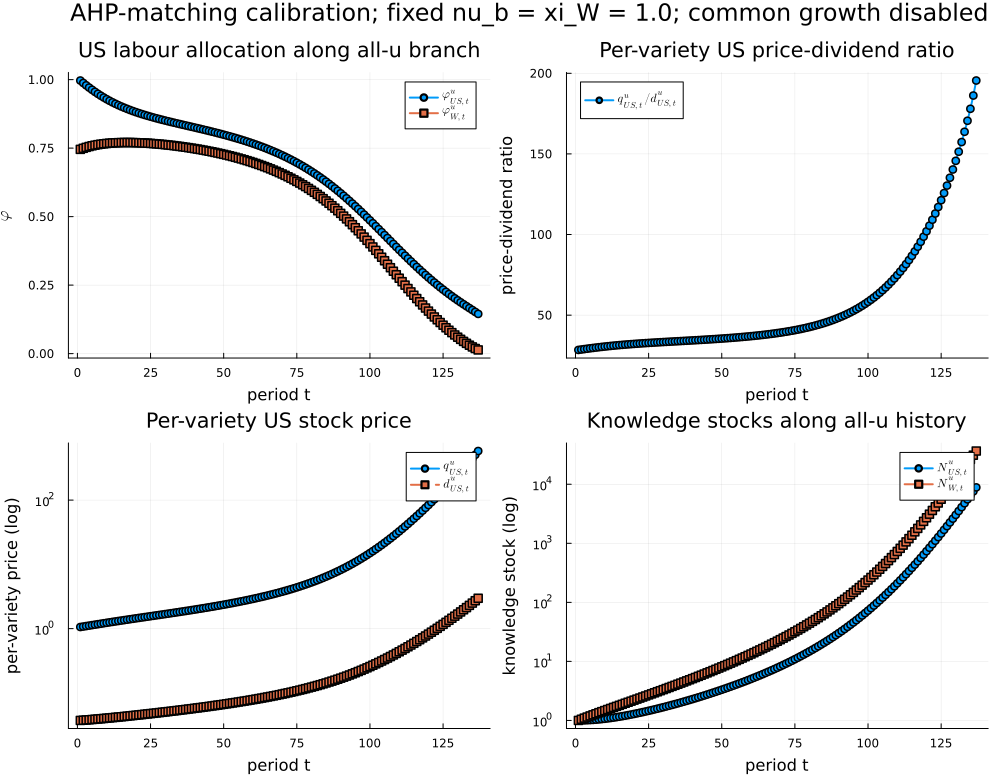

In [3]:
T = p.T_max
tt = 1:T

φ_US = [result.u_path[t].φ_US for t in tt]
φ_W  = [result.u_path[t].φ_W  for t in tt]
q_US = [result.u_path[t].q_US for t in tt]
d_US = [result.u_path[t].d_US for t in tt]
qd   = q_US ./ d_US
N_US = [result.u_path[t].N_US for t in tt]
N_W  = [result.u_path[t].N_W  for t in tt]

p1 = plot(tt, φ_US, lw=2, marker=:circle, label=L"\varphi_{US,t}^u",
          xlabel="period t", ylabel=L"\varphi",
          title="US labour allocation along all-u branch")
plot!(p1, tt, φ_W, lw=2, marker=:square, label=L"\varphi_{W,t}^u")

p2 = plot(tt, qd, lw=2, marker=:circle, label=L"q_{US,t}^u/d_{US,t}^u",
          xlabel="period t", ylabel="price-dividend ratio",
          title="Per-variety US price-dividend ratio")

p3 = plot(tt, q_US, lw=2, marker=:circle, label=L"q_{US,t}^u",
          xlabel="period t", ylabel="per-variety price (log)", yscale=:log10,
          title="Per-variety US stock price")
plot!(p3, tt, d_US, lw=2, marker=:square, label=L"d_{US,t}^u", ls=:dash)

p4 = plot(tt, N_US, lw=2, marker=:circle, label=L"N_{US,t}^u",
          xlabel="period t", ylabel="knowledge stock (log)", yscale=:log10,
          title="Knowledge stocks along all-u history")
plot!(p4, tt, N_W, lw=2, marker=:square, label=L"N_{W,t}^u")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 780),
     plot_title=EXPERIMENT_LABEL)


### 1.1 State-matched switch-to-$b$ labour allocations for the US and RoW

For each reported date $t$, `result.bgp_seq[t]` is the absorbing-regime
solution evaluated at the **same predetermined all-$u$ knowledge state**
$(N_{US,t}^u,N_{W,t}^u)$ stored in `result.u_path[t]`.  Define
$$
\varphi_{i,t}^{b\mid u}
=\varphi_i^b(N_{US,t}^u,N_{W,t}^u),\qquad i\in\{US,W\}.
$$
This is the state-matched labour allocation if the date-$t$ economy is in the
absorbing $b$ regime.  It is distinct from the all-$u$ policy
$\varphi_{i,t}^u$, and it is **not** a realized post-switch path: after an
actual switch, knowledge subsequently evolves under the $b$ allocations.
The absorbing solution holds $\nu_b=\xi_W=1.0$ fixed and imposes no
common-growth condition.


Max state-matching error: US 0.00e+00; RoW 0.00e+00
Max |ν_b_eff - ν_b| across state-matched absorbing solves: 0.00e+00


|   t | US: all-u | US: switch-to-b | gap (b-u) | RoW: all-u | RoW: switch-to-b | gap (b-u) |
| ---:| ---------:| ---------------:| ---------:| ----------:| ----------------:| ---------:|
|   1 |  0.996787 |        0.898340 | -0.098447 |   0.745480 |         0.781055 | +0.035575 |
|   2 |  0.987870 |        0.887703 | -0.100167 |   0.749393 |         0.784082 | +0.034689 |
|   5 |  0.963057 |        0.858621 | -0.104436 |   0.758476 |         0.791690 | +0.033215 |
|  10 |  0.928644 |        0.818623 | -0.110022 |   0.767062 |         0.800778 | +0.033716 |
|  15 |  0.902064 |        0.787103 | -0.114961 |   0.770271 |         0.806999 | +0.036728 |
|  30 |  0.850651 |        0.723059 | -0.127592 |   0.762620 |         0.817577 | +0.054957 |
|  60 |  0.766790 |        0.648226 | -0.118564 |   0.697636 |         0.827191 | +0.129555 |
|  90 |  0.585309 |        0.602294 | +0.016985 |   0.511857 |         0.831943 | +0.320086 |
| 110 |  0.378716 |        0.578372 | +0.199656 |   0.275225 |         0.834127 | +0.558901 |
| 130 |  0.194469 |        0.545981 | +0.351513 |   0.059877 |         0.836801 | +0.776923 |
| 137 |  0.144917 |        0.534523 | +0.389606 |   0.013451 |         0.837674 | +0.824223 |


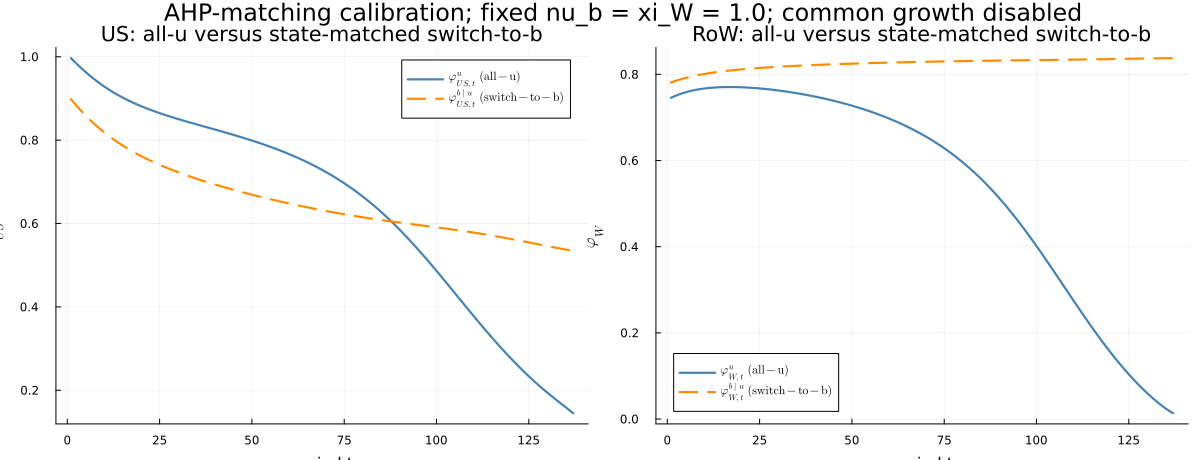

In [4]:
@assert length(result.bgp_seq) >= T

φ_US_switch_b = [result.bgp_seq[t].φ_US for t in tt]
φ_W_switch_b  = [result.bgp_seq[t].φ_W  for t in tt]

# Verify that the absorbing solution and all-u policy are evaluated at the
# same predetermined knowledge state at each t.
state_match_US = maximum(abs.([
    result.bgp_seq[t].N_US - result.u_path[t].N_US for t in tt
]))
state_match_W = maximum(abs.([
    result.bgp_seq[t].N_W - result.u_path[t].N_W for t in tt
]))
@printf("Max state-matching error: US %.2e; RoW %.2e\n", state_match_US, state_match_W)
@assert state_match_US < 1e-8 && state_match_W < 1e-8

# In the fixed-nu_b solver this cached field must equal the primitive at every state.
nu_b_eff_error = maximum(abs.([b.ν_b_eff - p.ν_b for b in result.bgp_seq[tt]]))
@printf("Max |ν_b_eff - ν_b| across state-matched absorbing solves: %.2e\n", nu_b_eff_error)
@assert nu_b_eff_error < 1e-12

φ_switch_horizons = unique(sort(filter(
    t -> 1 <= t <= T, [1, 2, 5, 10, 15, 30, 60, 90, 110, 130, T])))
switch_phi_table = [
    (t=t,
     φ_US_all_u=φ_US[t], φ_US_switch_b=φ_US_switch_b[t],
     Δφ_US=φ_US_switch_b[t] - φ_US[t],
     φ_RoW_all_u=φ_W[t], φ_RoW_switch_b=φ_W_switch_b[t],
     Δφ_RoW=φ_W_switch_b[t] - φ_W[t])
    for t in φ_switch_horizons
]

φ_table_lines = [
    "| t | US: all-u | US: switch-to-b | gap (b-u) | RoW: all-u | RoW: switch-to-b | gap (b-u) |",
    "|---:|---:|---:|---:|---:|---:|---:|",
]
append!(φ_table_lines, [
    @sprintf("| %d | %.6f | %.6f | %+.6f | %.6f | %.6f | %+.6f |",
             r.t, r.φ_US_all_u, r.φ_US_switch_b, r.Δφ_US,
             r.φ_RoW_all_u, r.φ_RoW_switch_b, r.Δφ_RoW)
    for r in switch_phi_table
])
display(Markdown.parse(join(φ_table_lines, "\n")))

p_US_switch_phi = plot(
    tt, φ_US, lw=2.2, color=:steelblue,
    label=L"\varphi_{US,t}^{u}\;\mathrm{(all\!-\!u)}",
    xlabel="period t", ylabel=L"\varphi_{US}",
    title="US: all-u versus state-matched switch-to-b",
)
plot!(p_US_switch_phi, tt, φ_US_switch_b, lw=2.2, ls=:dash, color=:darkorange,
      label=L"\varphi_{US,t}^{b\mid u}\;\mathrm{(switch\!-\!to\!-\!b)}")

p_W_switch_phi = plot(
    tt, φ_W, lw=2.2, color=:steelblue,
    label=L"\varphi_{W,t}^{u}\;\mathrm{(all\!-\!u)}",
    xlabel="period t", ylabel=L"\varphi_{W}",
    title="RoW: all-u versus state-matched switch-to-b",
)
plot!(p_W_switch_phi, tt, φ_W_switch_b, lw=2.2, ls=:dash, color=:darkorange,
      label=L"\varphi_{W,t}^{b\mid u}\;\mathrm{(switch\!-\!to\!-\!b)}")

plot(p_US_switch_phi, p_W_switch_phi, layout=(1,2), size=(1200, 460),
     plot_title=EXPERIMENT_LABEL)


### 1.2 Country-paired all-$u$ path panels

The figure below preserves the 12-variable all-$u$ path analysis from the
common-growth notebook.  Each panel overlays the U.S. and RoW paths for the
same country-level object, using the solved all-$u$ branch stored in
`result.u_path`.  Here the successor block is instead solved with fixed
$\nu_b=\xi_W=1.0$ and no common-growth condition.


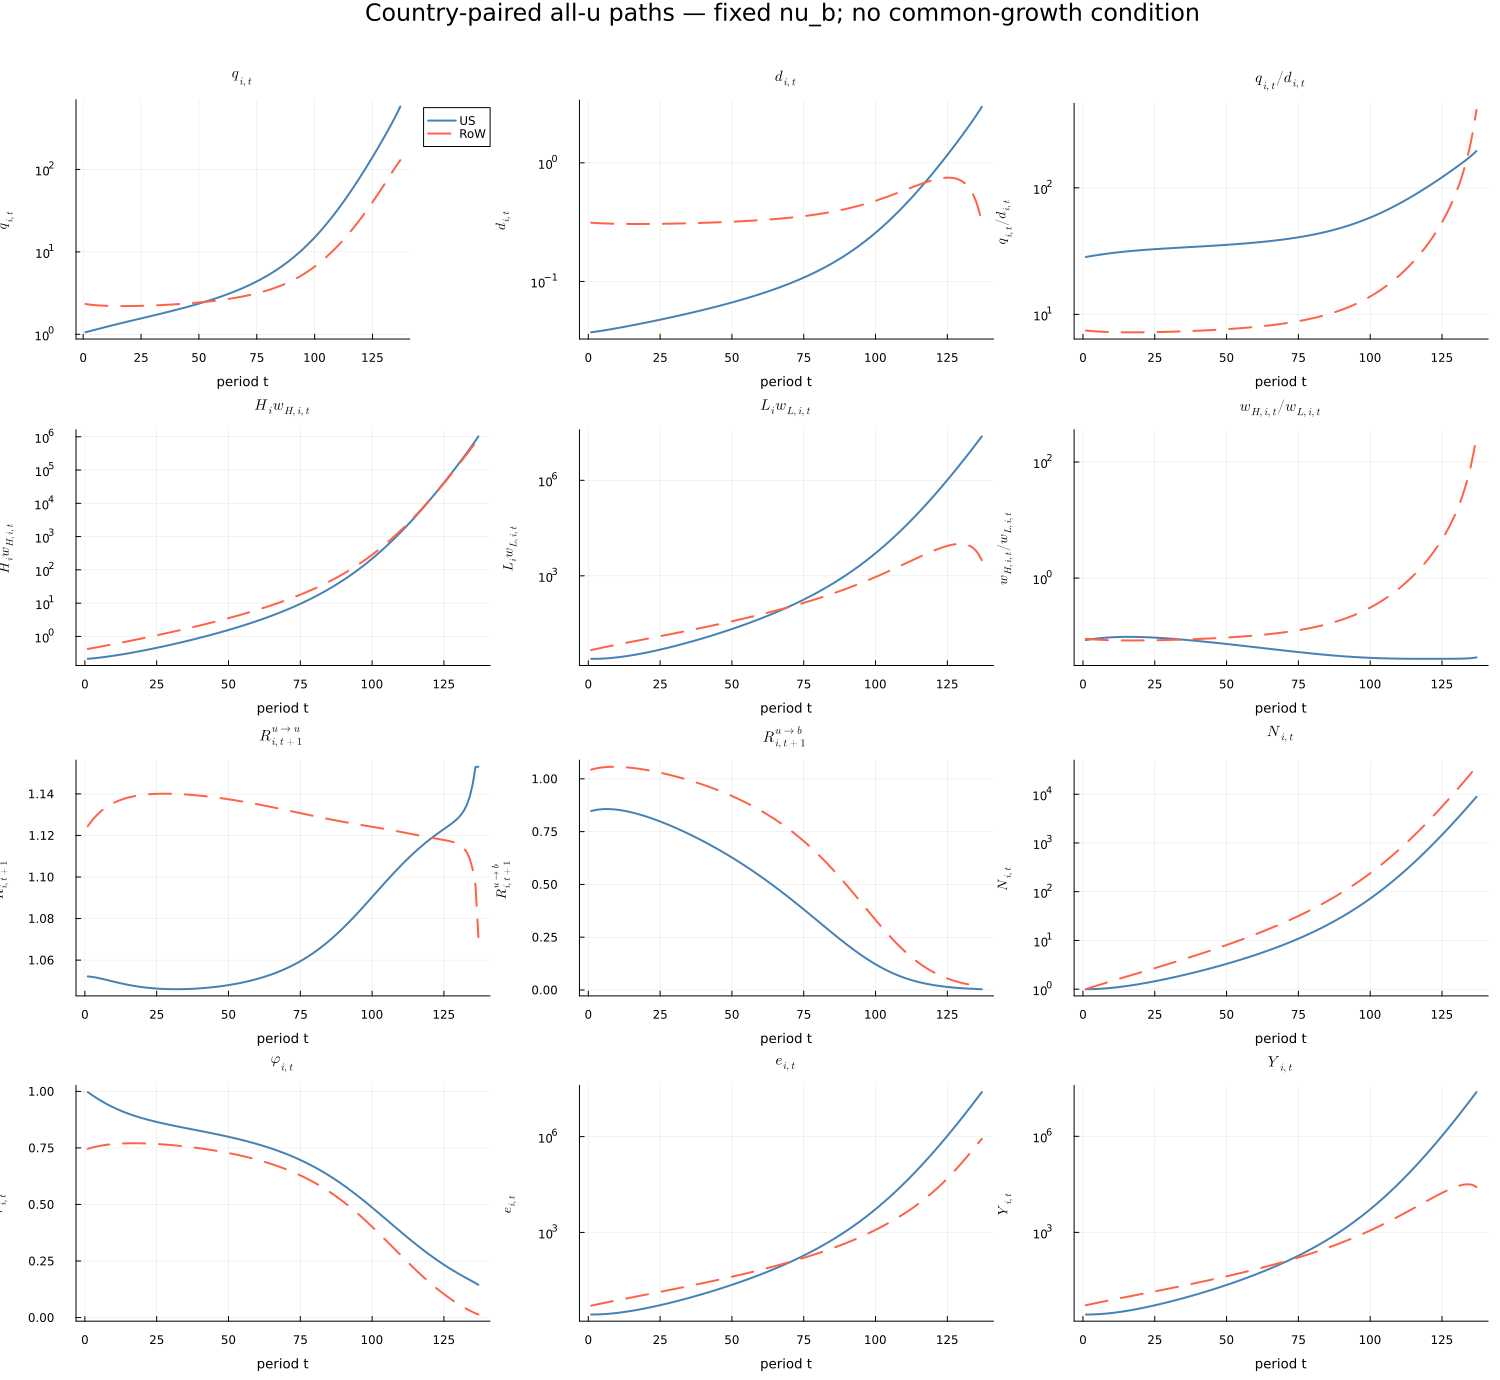

In [5]:
function positive_for_log_path(x)
    return [isfinite(v) && v > 0 ? v : eps(Float64) for v in Float64.(x)]
end

function country_series(us, row)
    return (; US=Float64.(us), RoW=Float64.(row))
end

function country_paired_all_u_path(result::ProductionSimulationResult)
    p = result.params
    states = result.u_path
    t = [s.t for s in states]

    q_US = [s.q_US for s in states]
    q_W  = [s.q_W  for s in states]
    d_US = [s.d_US for s in states]
    d_W  = [s.d_W  for s in states]

    us_blocks = [us_block(p, :u, s.φ_US, s.N_US) for s in states]
    row_blocks = [row_block(p, s.φ_W, s.N_W) for s in states]

    HwH_US = [b.w_H * p.H_US for b in us_blocks]
    HwH_W  = [b.w_H * p.H_W  for b in row_blocks]
    LwL_US = [b.w_L * p.L_US for b in us_blocks]
    LwL_W  = [b.w_L * p.L_W  for b in row_blocks]

    return (;
        t,
        q=country_series(q_US, q_W),
        d=country_series(d_US, d_W),
        pd=country_series(q_US ./ d_US, q_W ./ d_W),
        HwH=country_series(HwH_US, HwH_W),
        LwL=country_series(LwL_US, LwL_W),
        rel_wage=country_series(HwH_US ./ LwL_US, HwH_W ./ LwL_W),
        R_uu=country_series([s.R_US_u for s in states], [s.R_W_u for s in states]),
        R_ub=country_series([s.R_US_b for s in states], [s.R_W_b for s in states]),
        N=country_series([s.N_US for s in states], [s.N_W for s in states]),
        φ=country_series([s.φ_US for s in states], [s.φ_W for s in states]),
        e=country_series([s.e_US for s in states], [s.e_W for s in states]),
        Y=country_series([s.Y_US for s in states], [s.Y_W for s in states])
    )
end

country_all_u_variables = [
    (; field=:q,        title=L"q_{i,t}",                     ylabel=L"q_{i,t}",                     logscale=true),
    (; field=:d,        title=L"d_{i,t}",                     ylabel=L"d_{i,t}",                     logscale=true),
    (; field=:pd,       title=L"q_{i,t}/d_{i,t}",             ylabel=L"q_{i,t}/d_{i,t}",             logscale=true),
    (; field=:HwH,      title=L"H_i w_{H,i,t}",              ylabel=L"H_i w_{H,i,t}",              logscale=true),
    (; field=:LwL,      title=L"L_i w_{L,i,t}",              ylabel=L"L_i w_{L,i,t}",              logscale=true),
    (; field=:rel_wage, title=L"w_{H,i,t}/w_{L,i,t}",        ylabel=L"w_{H,i,t}/w_{L,i,t}",        logscale=true),
    (; field=:R_uu,     title=L"R_{i,t+1}^{u\to u}",         ylabel=L"R_{i,t+1}^{u\to u}",         logscale=false),
    (; field=:R_ub,     title=L"R_{i,t+1}^{u\to b}",         ylabel=L"R_{i,t+1}^{u\to b}",         logscale=false),
    (; field=:N,        title=L"N_{i,t}",                     ylabel=L"N_{i,t}",                     logscale=true),
    (; field=:φ,        title=L"\varphi_{i,t}",              ylabel=L"\varphi_{i,t}",              logscale=false),
    (; field=:e,        title=L"e_{i,t}",                     ylabel=L"e_{i,t}",                     logscale=true),
    (; field=:Y,        title=L"Y_{i,t}",                     ylabel=L"Y_{i,t}",                     logscale=true),
]

country_styles = [
    (; country=:US,  label="US",  color=:steelblue, linestyle=:solid),
    (; country=:RoW, label="RoW", color=:tomato,    linestyle=:dash),
]

function plot_country_paired_all_u_paths(path)
    panels = Any[]
    for (panel_idx, varspec) in enumerate(country_all_u_variables)
        panel = plot(xlabel="period t", ylabel=varspec.ylabel, title=varspec.title,
                     legend=(panel_idx == 1 ? :outertopright : false),
                     yscale=(varspec.logscale ? :log10 : :identity),
                     titlefontsize=10, guidefontsize=9, tickfontsize=8, legendfontsize=8)
        series = getproperty(path, varspec.field)
        for style in country_styles
            y = getproperty(series, style.country)
            yplot = varspec.logscale ? positive_for_log_path(y) : y
            plot!(panel, path.t, yplot, lw=2.0, color=style.color, ls=style.linestyle,
                  label=(panel_idx == 1 ? style.label : ""))
        end
        push!(panels, panel)
    end
    return plot(panels..., layout=(4,3), size=(1500, 1380),
                plot_title="Country-paired all-u paths — fixed nu_b; no common-growth condition")
end

country_all_u_path = country_paired_all_u_path(result)
country_all_u_fig = plot_country_paired_all_u_paths(country_all_u_path)
country_all_u_fig


## 2. Aggregate Quantities, Output Decomposition, and IPO Transfer

V4_3 eq. `country_output_income_identity` (line 217–222) gives the
**corrected** output decomposition:
$$
Y_{i,t} = e_{i,t} + \mathcal D_{i,t} - \mathcal I_{i,t},
$$
where $\mathcal I_{i,t} = (1-\varphi_{i,t}) H_i w_{H,i,t}$ is the IPO
transfer to R&D workers (V4_3 eq. `country_ipo_transfer`, line 211–214).
The V9 form $Y_i = e_i + \mathcal D_i$ omitted $\mathcal I_i$ — the
next code cell quantifies the difference along the u-path.

Aggregate market capitalisation: $\mathcal Q_{i,t} = N_{i,t+1} q_{i,t}$
(V4_3 eq. `country_stock_aggregation`).


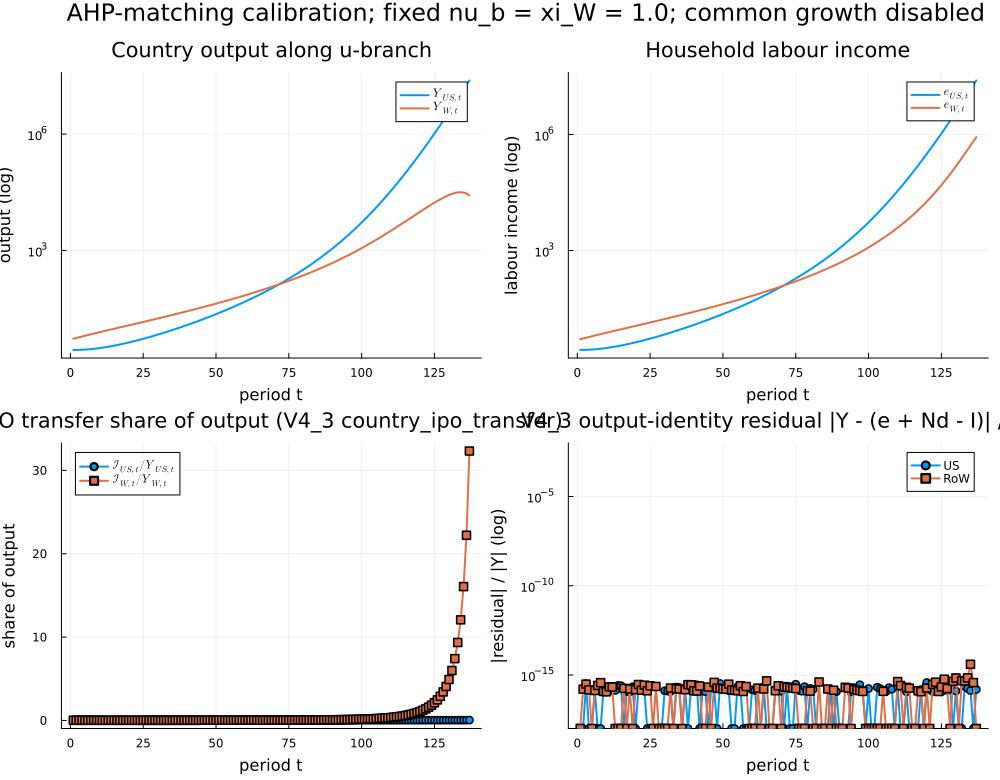

In [6]:
Y_US = [result.u_path[t].Y_US for t in tt]
Y_W  = [result.u_path[t].Y_W  for t in tt]
e_US = [result.u_path[t].e_US for t in tt]
e_W  = [result.u_path[t].e_W  for t in tt]
Q_US = [result.u_path[t].Q_US for t in tt]
Q_W  = [result.u_path[t].Q_W  for t in tt]
I_US = [result.u_path[t].I_US for t in tt]
I_W  = [result.u_path[t].I_W  for t in tt]
D_US = N_US .* d_US
rel_size = Y_W ./ Y_US

# V4_3 identity residual: Y_i - (e_i + N_i·d_i - I_i)
yid_res_US = [result.u_path[t].Y_US -
              (result.u_path[t].e_US + result.u_path[t].N_US*result.u_path[t].d_US -
               result.u_path[t].I_US) for t in tt]
yid_res_W = [result.u_path[t].Y_W -
             (result.u_path[t].e_W + result.u_path[t].N_W*result.u_path[t].d_W -
              result.u_path[t].I_W) for t in tt]

p1 = plot(tt, Y_US, lw=2, label=L"Y_{US,t}", yscale=:log10,
          xlabel="period t", ylabel="output (log)",
          title="Country output along u-branch")
plot!(p1, tt, Y_W, lw=2, label=L"Y_{W,t}")

p2 = plot(tt, e_US, lw=2, label=L"e_{US,t}", yscale=:log10,
          xlabel="period t", ylabel="labour income (log)",
          title="Household labour income")
plot!(p2, tt, e_W, lw=2, label=L"e_{W,t}")

# V4_3 IPO transfer panel
p3 = plot(tt, I_US ./ Y_US, lw=2, marker=:circle, label=L"\mathcal{I}_{US,t}/Y_{US,t}",
          xlabel="period t", ylabel="share of output",
          title="IPO transfer share of output (V4_3 country_ipo_transfer)")
plot!(p3, tt, I_W ./ Y_W, lw=2, marker=:square, label=L"\mathcal{I}_{W,t}/Y_{W,t}")

p4 = plot(tt, max.(abs.(yid_res_US) ./ abs.(Y_US), 1e-18), lw=2, marker=:circle,
          label="US", yscale=:log10, ylims=(1e-18, 1e-2),
          xlabel="period t", ylabel="|residual| / |Y| (log)",
          title="V4_3 output-identity residual |Y - (e + Nd - I)| / |Y|")
plot!(p4, tt, max.(abs.(yid_res_W) ./ abs.(Y_W), 1e-18), lw=2, marker=:square, label="RoW")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 780),
     plot_title=EXPERIMENT_LABEL)


## 3. Portfolio Policies and Risk-Free Rates

The V4_3 primary bond unknown is $\theta_{US,t}^*$ (RoW US-bond demand,
positive); $\theta_t$ (US household issuance, negative) is recovered.
Both are reported below.


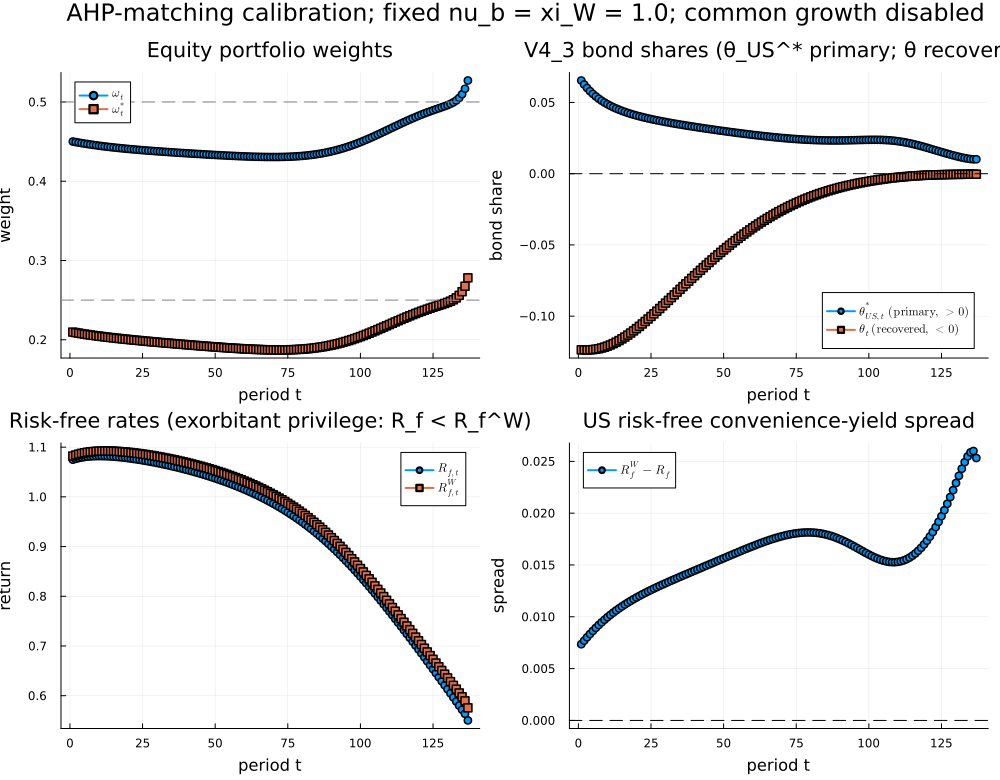

In [7]:
ω    = [result.u_path[t].ω         for t in tt]
ωs   = [result.u_path[t].ω_star    for t in tt]
θ    = [result.u_path[t].θ         for t in tt]
θUs  = [result.u_path[t].θ_US_star for t in tt]
R_f  = [result.u_path[t].R_f       for t in tt]
R_fW = [result.u_path[t].R_f_W     for t in tt]

p1 = plot(tt, ω, lw=2, marker=:circle, label=L"\omega_t",
          xlabel="period t", ylabel="weight",
          title="Equity portfolio weights")
plot!(p1, tt, ωs, lw=2, marker=:square, label=L"\omega_t^*")
hline!(p1, [p.ω̄, p.ω̄_star], ls=:dash, color=:gray, label="")

p2 = plot(tt, θUs, lw=2, marker=:circle,
          label=L"\theta_{US,t}^*\;(\mathrm{primary},\,> 0)",
          xlabel="period t", ylabel="bond share",
          title="V4_3 bond shares (θ_US^* primary; θ recovered)")
plot!(p2, tt, θ, lw=2, marker=:square,
      label=L"\theta_t\;(\mathrm{recovered},\,< 0)")
hline!(p2, [0.0], ls=:dash, color=:black, label="")

p3 = plot(tt, R_f, lw=2, marker=:circle, label=L"R_{f,t}",
          xlabel="period t", ylabel="return",
          title="Risk-free rates (exorbitant privilege: R_f < R_f^W)")
plot!(p3, tt, R_fW, lw=2, marker=:square, label=L"R_{f,t}^W")

p4 = plot(tt, R_fW .- R_f, lw=2, marker=:circle, label=L"R_f^W - R_f",
          xlabel="period t", ylabel="spread",
          title="US risk-free convenience-yield spread")
hline!(p4, [0.0], ls=:dash, color=:black, label="")

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 780),
     plot_title=EXPERIMENT_LABEL)


## 4. Market-Clearing Verification

We check the V4_3 value-form clearing equations:
$$
\mathcal Q_{US,t} = \omega_t S_t + \omega_t^* S_t^*,
\qquad
\mathcal Q_{W,t} = (1-\omega_t) S_t + (1-\omega_t^*) S_t^*,
$$
(V4_3 eqs. `intratemporal_QUS`, `intratemporal_QW`), and the V4_3 bond
clearing (line 727–729):
$$
\theta_t A_t + \theta_{US,t}^* A_t^* = 0,
\qquad
\theta_{W,t}^* A_t^* = 0.
$$
We also report the V4_3 output identity residual
$|Y_i - (e_i + \mathcal D_i - \mathcal I_i)|$ and the regularity
diagnostic $\Psi_t > 0$ (V4_3 `ass_regular_kernel`, line 1145).


Max normalized residuals along u-path:
  US stock-market clearing       : 5.71e-09
  RoW stock-market clearing      : 2.74e-08
  Bond clearing                  : 2.80e-18
  Aggregate market-cap identity  : 3.31e-08
  V4_3 Y=e+D-I (US)              : 3.79e-16
  V4_3 Y=e+D-I (RoW)             : 3.97e-15
  V4_3 ass_regular_kernel  min Ψ : 9.1469e-01   (all positive: true)


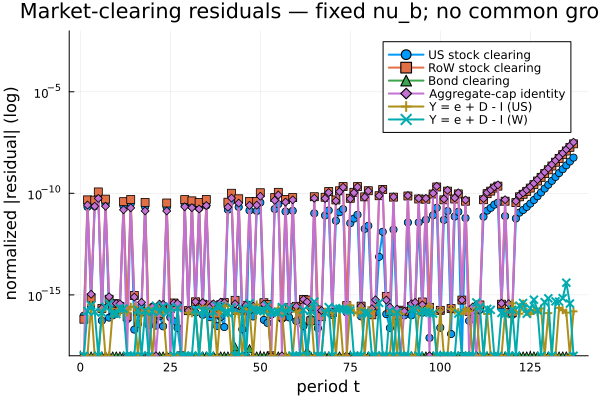

In [8]:
stock_err_US = zeros(T); stock_err_W = zeros(T); bond_err = zeros(T)
identity_err = zeros(T); yident_err_US = zeros(T); yident_err_W = zeros(T)
psi_path = zeros(T)
for t in 1:T
    s = result.u_path[t]
    savings_scale = max(s.A + s.A_star, 1e-12)
    stock_err_US[t] = abs(s.Q_US - s.ω*s.S - s.ω_star*s.S_star) / savings_scale
    stock_err_W[t]  = abs(s.Q_W - (1-s.ω)*s.S - (1-s.ω_star)*s.S_star) / savings_scale
    bond_err[t]     = abs(s.θ*s.A + s.θ_US_star*s.A_star) / savings_scale
    identity_err[t] = abs(s.Q_US + s.Q_W - (result.params.β*s.e_US + (result.params.β+result.params.χ)/(1+result.params.χ)*s.e_W)) / savings_scale
    yident_err_US[t]= abs(s.Y_US - (s.e_US + s.N_US*s.d_US - s.I_US)) / max(abs(s.Y_US), 1e-12)
    yident_err_W[t] = abs(s.Y_W  - (s.e_W  + s.N_W *s.d_W  - s.I_W)) / max(abs(s.Y_W), 1e-12)
    psi_path[t]     = s.Psi
end

p1 = plot(tt, max.(stock_err_US, 1e-18), lw=2, marker=:circle, label="US stock clearing",
          yscale=:log10, ylims=(1e-18, 1e-2),
          xlabel="period t", ylabel="normalized |residual| (log)",
          title="Market-clearing residuals — fixed nu_b; no common growth")
plot!(p1, tt, max.(stock_err_W, 1e-18),  lw=2, marker=:square,   label="RoW stock clearing")
plot!(p1, tt, max.(bond_err, 1e-18),     lw=2, marker=:utriangle, label="Bond clearing")
plot!(p1, tt, max.(identity_err, 1e-18), lw=2, marker=:diamond,   label="Aggregate-cap identity")
plot!(p1, tt, max.(yident_err_US, 1e-18), lw=2, marker=:cross, label="Y = e + D - I (US)")
plot!(p1, tt, max.(yident_err_W , 1e-18), lw=2, marker=:xcross, label="Y = e + D - I (W)")

@printf("Max normalized residuals along u-path:\n")
@printf("  US stock-market clearing       : %.2e\n", maximum(stock_err_US))
@printf("  RoW stock-market clearing      : %.2e\n", maximum(stock_err_W))
@printf("  Bond clearing                  : %.2e\n", maximum(bond_err))
@printf("  Aggregate market-cap identity  : %.2e\n", maximum(identity_err))
@printf("  V4_3 Y=e+D-I (US)              : %.2e\n", maximum(yident_err_US))
@printf("  V4_3 Y=e+D-I (RoW)             : %.2e\n", maximum(yident_err_W))
@printf("  V4_3 ass_regular_kernel  min Ψ : %.4e   (all positive: %s)\n",
        minimum(psi_path), all(>(0), psi_path))

# Soft assertion (warn but do not error)
if !all(>(0), psi_path)
    @warn "V4_3 ass_regular_kernel violated at some t along u-path."
end
p1


## 5. φ-Decay vs. the V4_3 Reference Curve $N_{US,t}^{-\psi_{US}/\rho_{US}}$

V4_3 Lemma `lem_prod_orders` (eq. `phi_u_upper_order`) proves the one-sided
**upper** bound, within its maintained parameter region,
$\varphi_{US,t}^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}}$
with $\psi_{US} = (\xi_u - \nu_u)(\rho_{US} - 1)$ — only $\lesssim$, since
$\varphi_{US,t}^u$ is an equilibrium object, not a primitive.  The requested
AHP-matching calibration instead satisfies $\xi_u=2.25>\nu_u=1.75>\nu_b=1.0$.
The curve is therefore an economically relevant finite-horizon benchmark.  Its
visual fit alone, however, is not a substitute for verifying every hypothesis
and the asymptotic tail conditions of the theorem.

V4_3 production-side decay exponent: -ψ_US/ρ_US = -0.2500


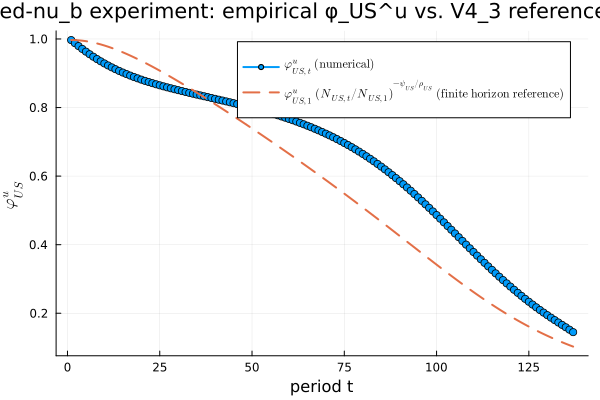

In [9]:
ψ_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
decay = ψ_US / p.ρ_US
@printf("V4_3 production-side decay exponent: -ψ_US/ρ_US = -%.4f\n", decay)

# The AHP calibration satisfies ξ_u > ν_u > ν_b.  This plotted curve is
# still a finite-horizon reference, distinct from a full tail certification.
bound = φ_US[1] .* (N_US ./ N_US[1]).^(-decay)

plot(tt, φ_US, lw=2, marker=:circle, label=L"\varphi_{US,t}^u\,(\mathrm{numerical})",
     xlabel="period t", ylabel=L"\varphi_{US}^u",
     title="Fixed-nu_b experiment: empirical φ_US^u vs. V4_3 reference curve")
plot!(tt, bound, lw=2, ls=:dash,
      label=L"\varphi_{US,1}^u\,(N_{US,t}/N_{US,1})^{-\psi_{US}/\rho_{US}}\ \mathrm{(finite\ horizon\ reference)}")

## Summary

- This isolated experiment fixes $\nu_b=\xi_W=1.0$ and disables the
  common-growth condition; no absorbing-state solve recalibrates $\nu_b$.
- The primitive tuple is the AHP-matching calibration used in Notebooks 02 and
  03: $(\beta,\gamma,\pi)=(0.45,0.25,0.75)$, $a_{US}=0.20$,
  $\vartheta_{US}=0.85$, $a_W=0.06$, $(H_W,L_W)=(3,3)$,
  $(A^u_{X,US},A^u_{L,US})=(15,1.5)$,
  $(\xi_u,\nu_u,\nu_b,\xi_W)=(2.25,1.75,1.0,1.0)$, and the same
  portfolio and adjustment-cost parameters.
- Starting from the source horizon $T=100$, no-buffer warm continuation solves
  $T=30,35,\ldots,135,136,137$.  Every displayed path ends at the verified
  hard-valid frontier $T=137$, rather than using an extrapolated terminal tail.
- The forward-backward iteration solves the V4_3 reduced seven-equation Markov
  competitive-equilibrium system along the all-$u$ branch.
- For both the U.S. and RoW, the notebook separately reports
  $\varphi_{i,t}^{u}$ and the state-matched switch allocation
  $\varphi_{i,t}^{b\mid u}$ from `result.bgp_seq[t]`; the latter is a
  counterfactual policy at the same predetermined all-$u$ state, not a realized
  post-switch trajectory.
- The original labour-allocation, per-variety price/dividend, country-paired
  12-panel, aggregate-output, IPO-transfer, portfolio, risk-free-rate,
  market-clearing, and $\varphi$-decay analyses are retained at the longer horizon.
- $\varphi_{US,t}^u$ is compared with the V4_3 one-sided upper-bound curve
  $N_{US,t}^{-\psi_{US}/\rho_{US}}$.  The AHP calibration satisfies
  $\xi_u>\nu_u>\nu_b$; nevertheless, a finite-horizon plot does not by itself
  establish the theorem's full asymptotic tail conditions.
- The notebook asserts the stronger equilibrium hard-validity gate at every
  continuation horizon: branch convergence, both residual maxima below $10^{-5}$,
  every reported absorbing solution valid, $\Psi\geq0.02$, all equity weights
  at least $0.01$, and $0.01\leq\theta^*_{US,t}<0.9$.
- Numerical hard validity remains conceptually separate from the HKT tail-entry
  and bubble-bound certification reported in Notebook 02.
